In [1]:
%load_ext autoreload
%autoreload 2

import numpy as np
import matplotlib.pyplot as plt
import pymc as pm
import arviz as az
import importlib

#from pymcsimmod.models.jax_model import JaxModel
from pymcsimmod import create_model
from pymcsimmod import BayesianODEModel

# Set plot styling
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

# Import the model

Use the built-in `pk1_input.model`

C:\Users\tjzur\models\PyMCSimMod\src\pymcsimmod\models\jax_model.py:129: UserWarning: Event times [np.float64(3.0), np.float64(6.0)] not found in time grid - automatically adding them to ensure accurate event handling. To avoid this message, consider using: np.arange(0.0, 12.121, 0.121) or explicitly include event times in your time array.
  validated_events, modified_times = check_events(
C:\Users\tjzur\models\PyMCSimMod\src\pymcsimmod\models\jax_model.py:129: UserWarning: Removed 1 time points that were within numerical precision of event times to avoid numerical issues. This is normal behavior following deSolve's event handling.
  validated_events, modified_times = check_events(


{'Vdc': 0.1, 'k01': 1, 'k12': 0.5, 'MW': 150, 'A0_init': 0, 'A1_init': 0, 'A2_init': 0, 'AUC_init': 0, 'OralDose': 50.0, 'OralDur': 0.01, 'IVDose': 0, 'IVDur': 0.01}


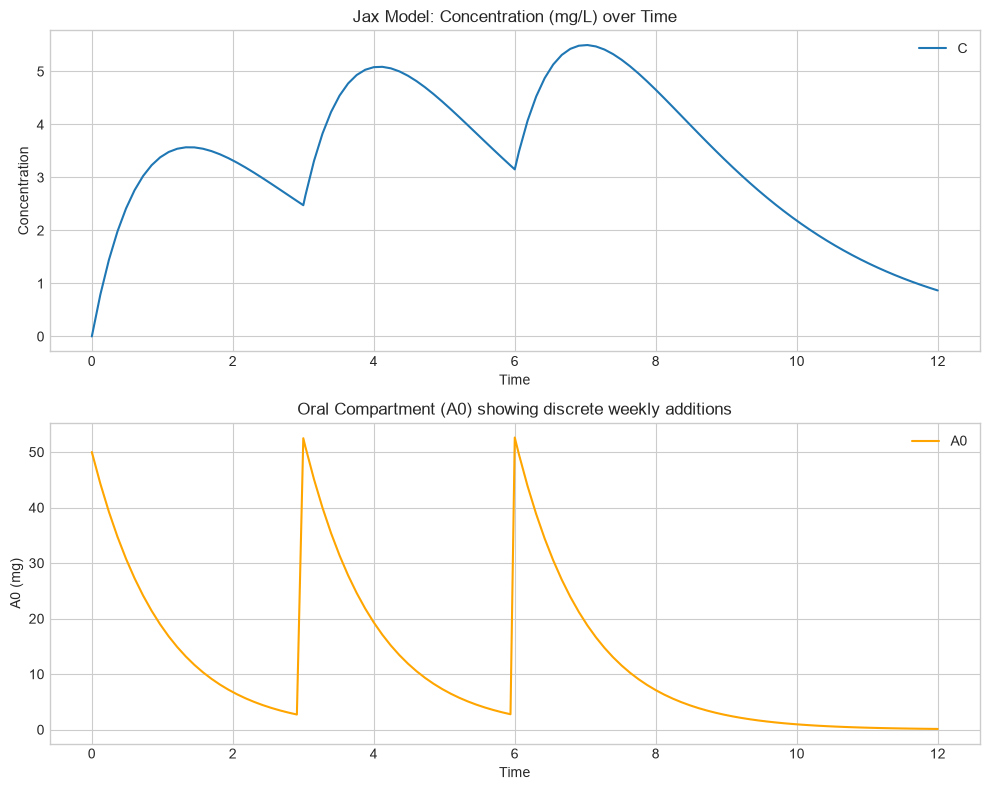

In [2]:
with importlib.resources.path('pymcsimmod.data', 'pk1_input.model') as filename:
    jax_model = create_model(filename, backend="jax")

jax_model.update_constants(OralDose=50.0)


jax_model.assign_forcing_function('M_in', 'ConstFunc', value=70)
# 2. Define weekly dosing using an event scheduler
jax_model.assign_event('A0', 'NDoses', t0_list=[0.0, 3, 6], value='OralDose')
#jax_model.assign_event('A0', 'PerDoses', t0=0.0, period=7.0, value='OralDose')

# Run simulation
times = np.linspace(0, 12, 100)
solution = jax_model.run_model(times)

# Plot results
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8))
solution.plot_results(variables='C', ax=ax1)
ax1.set_title('Jax Model: Concentration (mg/L) over Time')
ax1.set_ylabel('Concentration')

solution.plot_results(variables='A0', ax=ax2, color='orange')
ax2.set_title('Oral Compartment (A0) showing discrete weekly additions')
ax2.set_ylabel('A0 (mg)')
print(jax_model.parameters)
plt.tight_layout()
plt.show()

# PyMC Sample

Create generative model from ODE and sample parameters

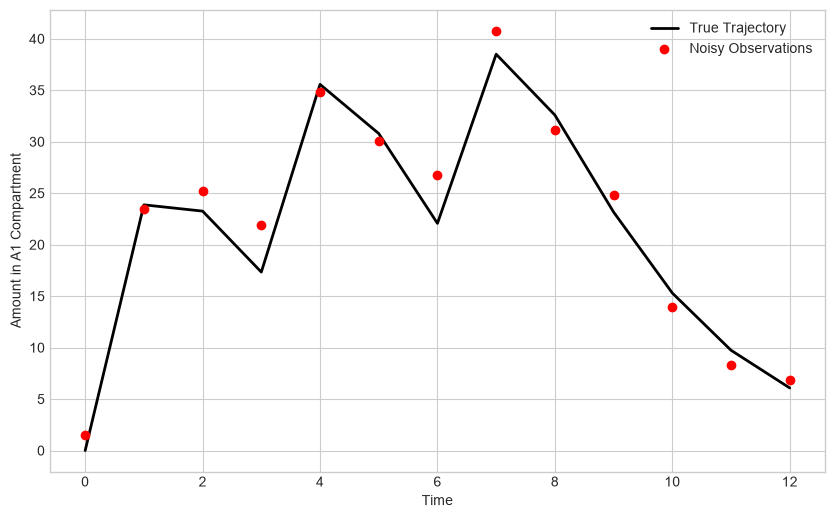

In [3]:
times = np.linspace(0, 12, 13)
sim = jax_model.run_model(times)
true_y = np.array(sim.dataframe['A1'])

# Add observational noise
np.random.seed(42)
noise_sigma = 3
observed_data = true_y + np.random.normal(0, noise_sigma, size=len(times))

plt.plot(times, true_y, label='True Trajectory', color='black', lw=2)
plt.scatter(times, observed_data, label='Noisy Observations', color='red', zorder=5)
plt.xlabel('Time')
plt.ylabel('Amount in A1 Compartment')
plt.legend()
plt.show()

In [4]:
# Initialize the wrapper
bayes_model = BayesianODEModel(jax_model, times=times)


with pm.Model() as pm_model:
    # Prior distributions
    Vdc = pm.LogNormal("Vdc", mu=np.log(jax_model.parameters['Vdc']), sigma=0.1)
    k01 = pm.LogNormal("k01", mu=np.log(jax_model.parameters['k01']), sigma=0.1)
    k12 = pm.LogNormal("k12", mu=np.log(jax_model.parameters['k12']), sigma=0.1)
    
    # Run the ODE solver inside PyMC context
    predictions = bayes_model.solve(
        params={"Vdc": Vdc, "k01": k01, "k12": k12},
        observed_vars=["A1"]
    )
    
    # Observational noise prior and likelihood
    sigma = pm.Exponential("sigma", lam = 1.0/0.1)
    pm.Deterministic('A1_pred', predictions)
    pm.Normal("A1", mu=predictions, sigma=sigma, observed=observed_data)

    # Sample the model
    idata = pm.sample(draws=1000, tune=1000, chains=2, random_seed=42)

c:\Users\tjzur\models\PyMCSimMod\.venv\Lib\site-packages\pytensor\gradient.py:1327: FutureWarning: MCSimModOp should implement `pullback` instead of `L_op`/`grad`. Direct `L_op`/`grad` implementations are deprecated and will stop being called in a future version.
  input_grads = node.op.pullback(inputs, node.outputs, new_output_grads)
NUTS[nutpie]: [Vdc, k01, k12, sigma]
c:\Users\tjzur\models\PyMCSimMod\.venv\Lib\site-packages\pytensor\gradient.py:1327: FutureWarning: MCSimModOp should implement `pullback` instead of `L_op`/`grad`. Direct `L_op`/`grad` implementations are deprecated and will stop being called in a future version.
  input_grads = node.op.pullback(inputs, node.outputs, new_output_grads)
c:\Users\tjzur\models\PyMCSimMod\.venv\Lib\site-packages\pytensor\link\numba\dispatch\basic.py:234: UserWarning: Numba will use object mode to run MCSimModOp{_n_params=3, _n_y0=0, _output_shape=(13,), _name='MCSimModOp_JaxModel'}'s perform method. Set `pytensor.config.compiler_verbose = T

Output()

       mean     sd eti89_lb eti89_ub  ess_bulk  ess_tail r_hat mcse_mean  \
Vdc  0.1007   0.01    0.085     0.12      2811      1710  1.00   0.00019   
k01   0.992  0.054     0.91      1.1      3017      1483  1.00     0.001   
k12  0.4856  0.009     0.47      0.5      2062      1371  1.00    0.0002   

     mcse_sd  
Vdc  0.00013  
k01  0.00073  
k12  0.00015  


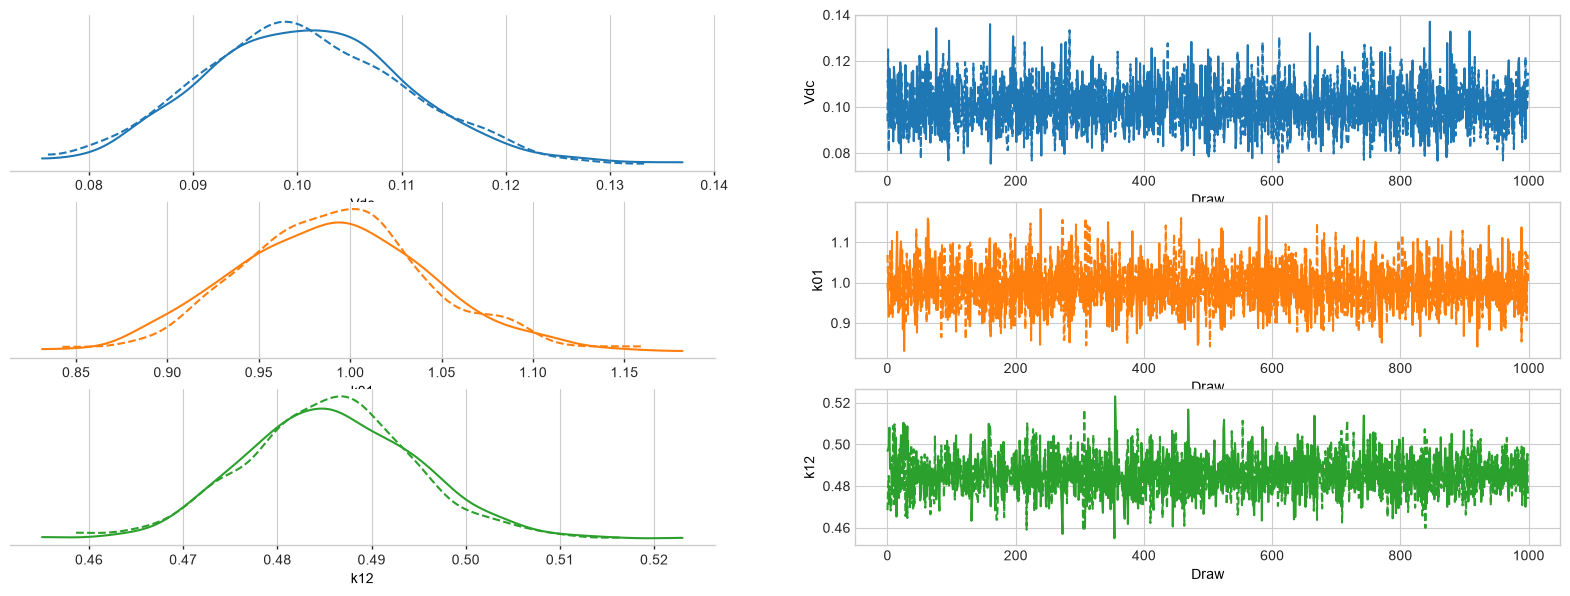

In [5]:
# Print summary table
print(az.summary(idata, var_names=["Vdc", "k01", "k12"]))

# Plot parameter traces
az.plot_trace_dist(idata, var_names=["Vdc", "k01", "k12"])
plt.show()

C:\Users\tjzur\models\PyMCSimMod\src\pymcsimmod\pymc\computed.py:115: UserWarning: Event times [np.float64(3.0), np.float64(6.0)] not found in time grid - automatically adding them to ensure accurate event handling. To avoid this message, consider using: np.arange(0.0, 12.060, 0.060) or explicitly include event times in your time array.
  _, plot_times = check_events(
C:\Users\tjzur\models\PyMCSimMod\src\pymcsimmod\pymc\computed.py:115: UserWarning: Removed 1 time points that were within numerical precision of event times to avoid numerical issues. This is normal behavior following deSolve's event handling.
  _, plot_times = check_events(


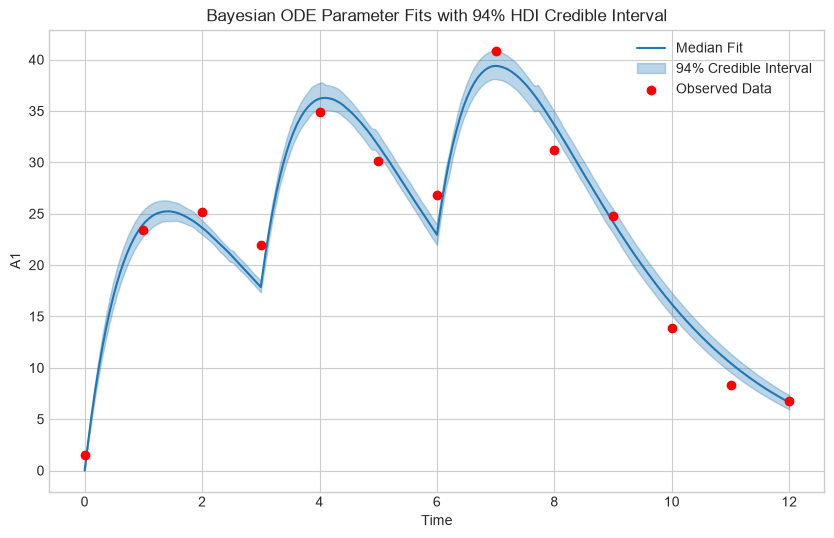

In [7]:
computed = bayes_model.posterior_predictive(idata)

# Plot posterior predictive intervals on a denser time grid
dense_times = np.linspace(0, 12, 200)

fig, ax = plt.subplots(figsize=(10, 6))
computed.plot_predictive(var_name="A1", ax=ax, hdi_prob=0.94, num_samples=200, times=dense_times)

# Overlay data points
ax.scatter(times, observed_data, color='red', label='Observed Data', zorder=5)
ax.legend()
ax.set_title("Bayesian ODE Parameter Fits with 94% HDI Credible Interval")
plt.show()